# Experiment 1: Pre-Normalized Response Analysis

| Part | What it does | Key question |
|------|-------------|--------------|
| **A** | Exhaustive enumeration over all C(L,l) subsets | Does R grow exponentially with set size? |
| **B** | Random (S,θ) sampling — per-neuron & per-stimulus views | Does D(S,θ) concentrate? (Activity Cap) |
| **C** | Lengthscale comparison (broad λ=3 vs sharp λ=1) | How does tuning sharpness affect D(S,θ)? |
| **D** | Sub-tuning curve visualisation G[n,k,θ] = exp(f_n(k,θ)) | What do the multiplicative atoms look like? |

Each part can be run **independently** — just run the first two cells (Setup + Config), then jump to any part.


## Cell 1 — Setup: Path & Imports

In [1]:
import sys
import os
from pathlib import Path

# ── Set project root ──
# This notebook lives in experiments/core_basics/
# Project root is two levels up
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR

# Walk upward until we find the 'core' directory
for _ in range(5):
    if (PROJECT_ROOT / 'core').is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise FileNotFoundError(
        "Could not find 'core/' directory. "
        "Make sure you run this notebook from within the project tree."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Notebook dir: {NOTEBOOK_DIR}")

# ── Imports ──
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # safe for Jupyter
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from math import comb
from scipy import stats as sp_stats
import time
import gc

# Use tqdm.notebook if available, else fallback
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# ── Project imports ──
from core.gaussian_process import (
    generate_neuron_population,
    compute_pre_normalized_response,
)
from core.divisive_normalization import (
    compute_total_activity,
    compute_per_item_activity,
)
from analysis.separability import (
    analyze_population_separability,
    summarize_separability,
)

print("All imports OK ✓")


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1
Notebook dir: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/experiments/core_basics
All imports OK ✓


## Cell 2 — Configuration

Adjust these parameters before running any Part.

> **Memory note**: If `n_orientations=200` causes a crash, try `100` or `64` first
> to verify everything works, then increase.


In [2]:
# ════════════════════════════════════════════════════
# CONFIGURATION — edit these freely
# ════════════════════════════════════════════════════
cfg = {
    'n_neurons':        10,
    'n_orientations':   200,   # reduce to 64 or 100 if memory is tight
    'n_locations':      8,
    'set_sizes':        [2, 4, 6, 8],
    'seed':             42,
    'lambda_base':      0.3,
    'sigma_lambda':     0.5,
    'n_random_subsets':  50,
    'n_theta_draws':     5,
    'n_unique_target':  250,
    'gain_variability':  0.2,
}

N         = cfg['n_neurons']
L         = cfg['n_locations']
n_ori     = cfg['n_orientations']
seed      = cfg['seed']
set_sizes = cfg['set_sizes']

OUTPUT_DIR = PROJECT_ROOT / 'results' / 'exp1_notebook'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"N={N}  |  n_orientations={n_ori}  |  L={L}  |  seed={seed}")
print(f"Output → {OUTPUT_DIR}")


N=10  |  n_orientations=200  |  L=8  |  seed=42
Output → /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/results/exp1_notebook


## Cell 3 — Generate Neuron Population

Creates the shared population used by Parts A, B, and the main Part D condition.
Run once; all parts below reference `population` and `G_stacked`.


In [3]:
gc.collect()  # free any stale memory before allocation

population = generate_neuron_population(
    n_neurons=N,
    n_orientations=n_ori,
    n_locations=L,
    base_lengthscale=cfg['lambda_base'],
    lengthscale_variability=cfg['sigma_lambda'],
    seed=seed,
    gain_variability=cfg['gain_variability'],
)


# G_stacked[n, k, θ] = exp(f_n(k, θ))
G_stacked = np.stack([np.exp(neuron['f_samples']) for neuron in population])

print(f"Population: {len(population)} neurons")
print(f"G_stacked shape: {G_stacked.shape}  (N, L, n_orientations)")
print(f"G range: [{G_stacked.min():.4f}, {G_stacked.max():.4f}]")
print(f"G_stacked memory: {G_stacked.nbytes / 1024**2:.1f} MB")


Population: 10 neurons
G_stacked shape: (10, 8, 200)  (N, L, n_orientations)
G range: [0.0310, 123.8464]
G_stacked memory: 0.1 MB


---
## Part D — Sub-Tuning Curves G[n, k, θ] = exp(f_n(k, θ))

The **multiplicative atoms** that compose the pre-DN product response.
- **D1**: Multi-seed (same λ, different GP draws)
- **D2**: Multi-lengthscale (same seed, varied λ)


In [5]:
PART_D_LAMBDAS = [0.1, 0.3, 1.0, 3.0]
d_seeds   = [seed, seed+1, seed+2]
d_lambdas = PART_D_LAMBDAS

print(f"Part D: n_orientations={n_ori}")
print(f"  D1 seeds: {d_seeds}")
print(f"  D2 lambdas: {d_lambdas}")

# One random subset per set size (shared)
rng_d = np.random.default_rng(seed + 4000)
subsets_per_l = {}
for l in set_sizes:
    subsets_per_l[l] = tuple(sorted(rng_d.choice(L, size=l, replace=False)))
    print(f"  l={l}: subset = {subsets_per_l[l]}")

# D1: Multi-seed
print("\nD1: generating populations...")
d1_G = {}
for s in d_seeds:
    pop_d = generate_neuron_population(
        n_neurons=N, n_orientations=n_ori, n_locations=L,
        base_lengthscale=cfg['lambda_base'], lengthscale_variability=cfg['sigma_lambda'],
        seed=s, gain_variability=cfg['gain_variability'],
    )
    d1_G[s] = np.stack([np.exp(n['f_samples']) for n in pop_d])
    print(f"  seed={s}: shape={d1_G[s].shape}  range=[{d1_G[s].min():.4f}, {d1_G[s].max():.4f}]")
    del pop_d; gc.collect()

# D2: Multi-lengthscale
print("\nD2: generating populations...")
d2_G = {}
for lam in d_lambdas:
    pop_d = generate_neuron_population(
        n_neurons=N, n_orientations=n_ori, n_locations=L,
        base_lengthscale=lam, lengthscale_variability=0.0,
        seed=seed, gain_variability=cfg['gain_variability'],
    )
    d2_G[lam] = np.stack([np.exp(n['f_samples']) for n in pop_d])
    print(f"  λ={lam:.2f}: shape={d2_G[lam].shape}  range=[{d2_G[lam].min():.4f}, {d2_G[lam].max():.4f}]")
    del pop_d; gc.collect()

print("\nPart D data ready ✓")


Part D: n_orientations=200
  D1 seeds: [42, 43, 44]
  D2 lambdas: [0.1, 0.3, 1.0, 3.0]
  l=2: subset = (0, 5)
  l=4: subset = (0, 1, 2, 7)
  l=6: subset = (1, 2, 3, 5, 6, 7)
  l=8: subset = (0, 1, 2, 3, 4, 5, 6, 7)

D1: generating populations...
  seed=42: shape=(10, 8, 200)  range=[0.0310, 123.8464]
  seed=43: shape=(10, 8, 200)  range=[0.0249, 93.5662]
  seed=44: shape=(10, 8, 200)  range=[0.0086, 856.7358]

D2: generating populations...
  λ=0.10: shape=(10, 8, 200)  range=[0.0129, 104.6903]
  λ=0.30: shape=(10, 8, 200)  range=[0.0272, 105.3196]
  λ=1.00: shape=(10, 8, 200)  range=[0.0354, 36.0041]
  λ=3.00: shape=(10, 8, 200)  range=[0.0180, 21.5115]

Part D data ready ✓


### D1 — Multi-Seed Plots

/var/folders/yj/t42cs9hx1vggcmxsxd8zgrhc0000gn/T/ipykernel_2008/2260767750.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_plot)


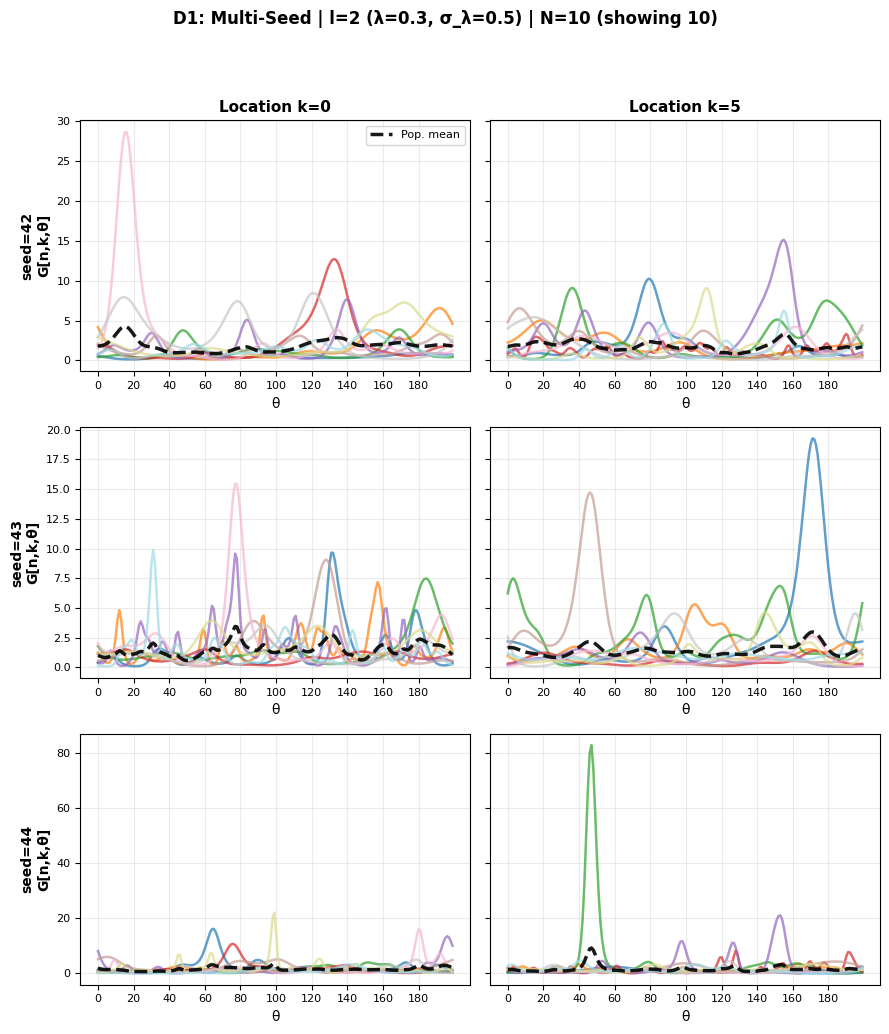

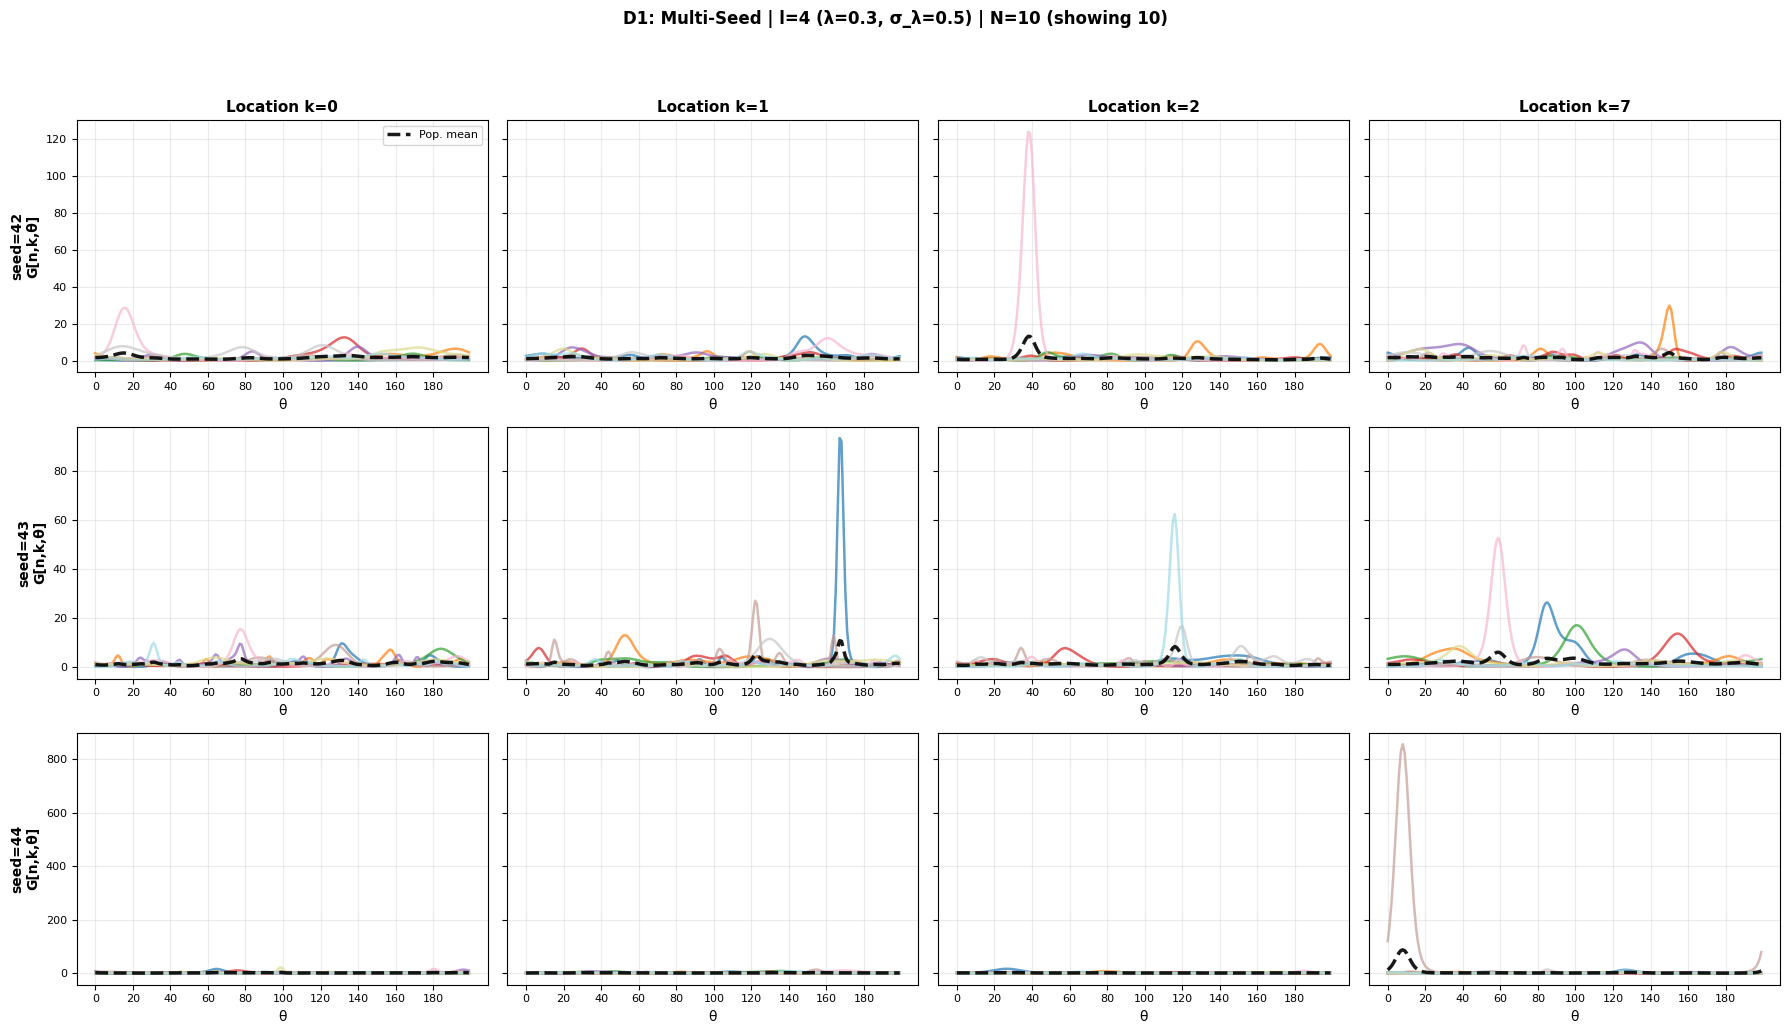

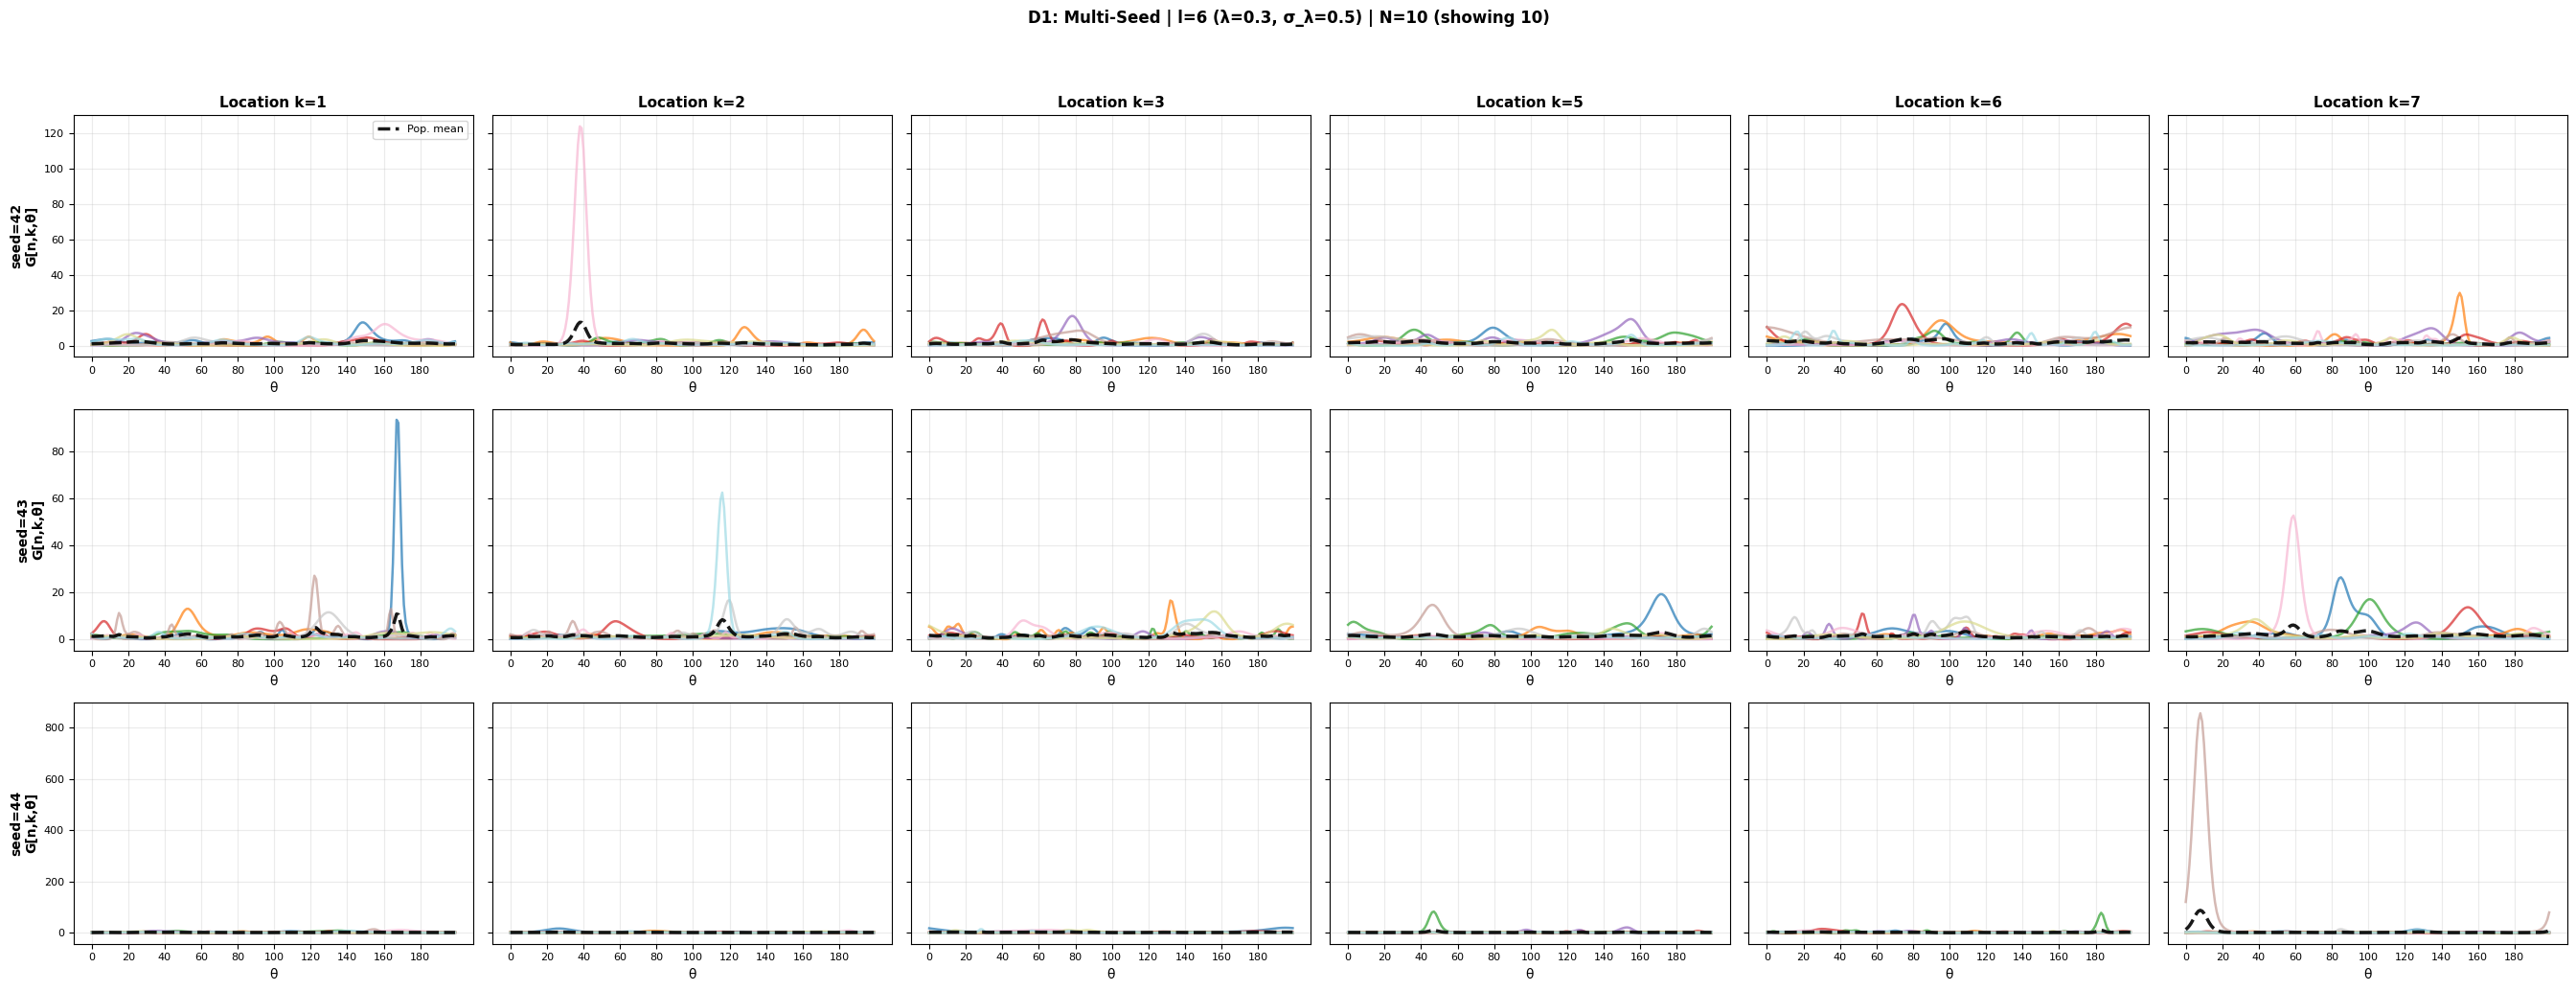

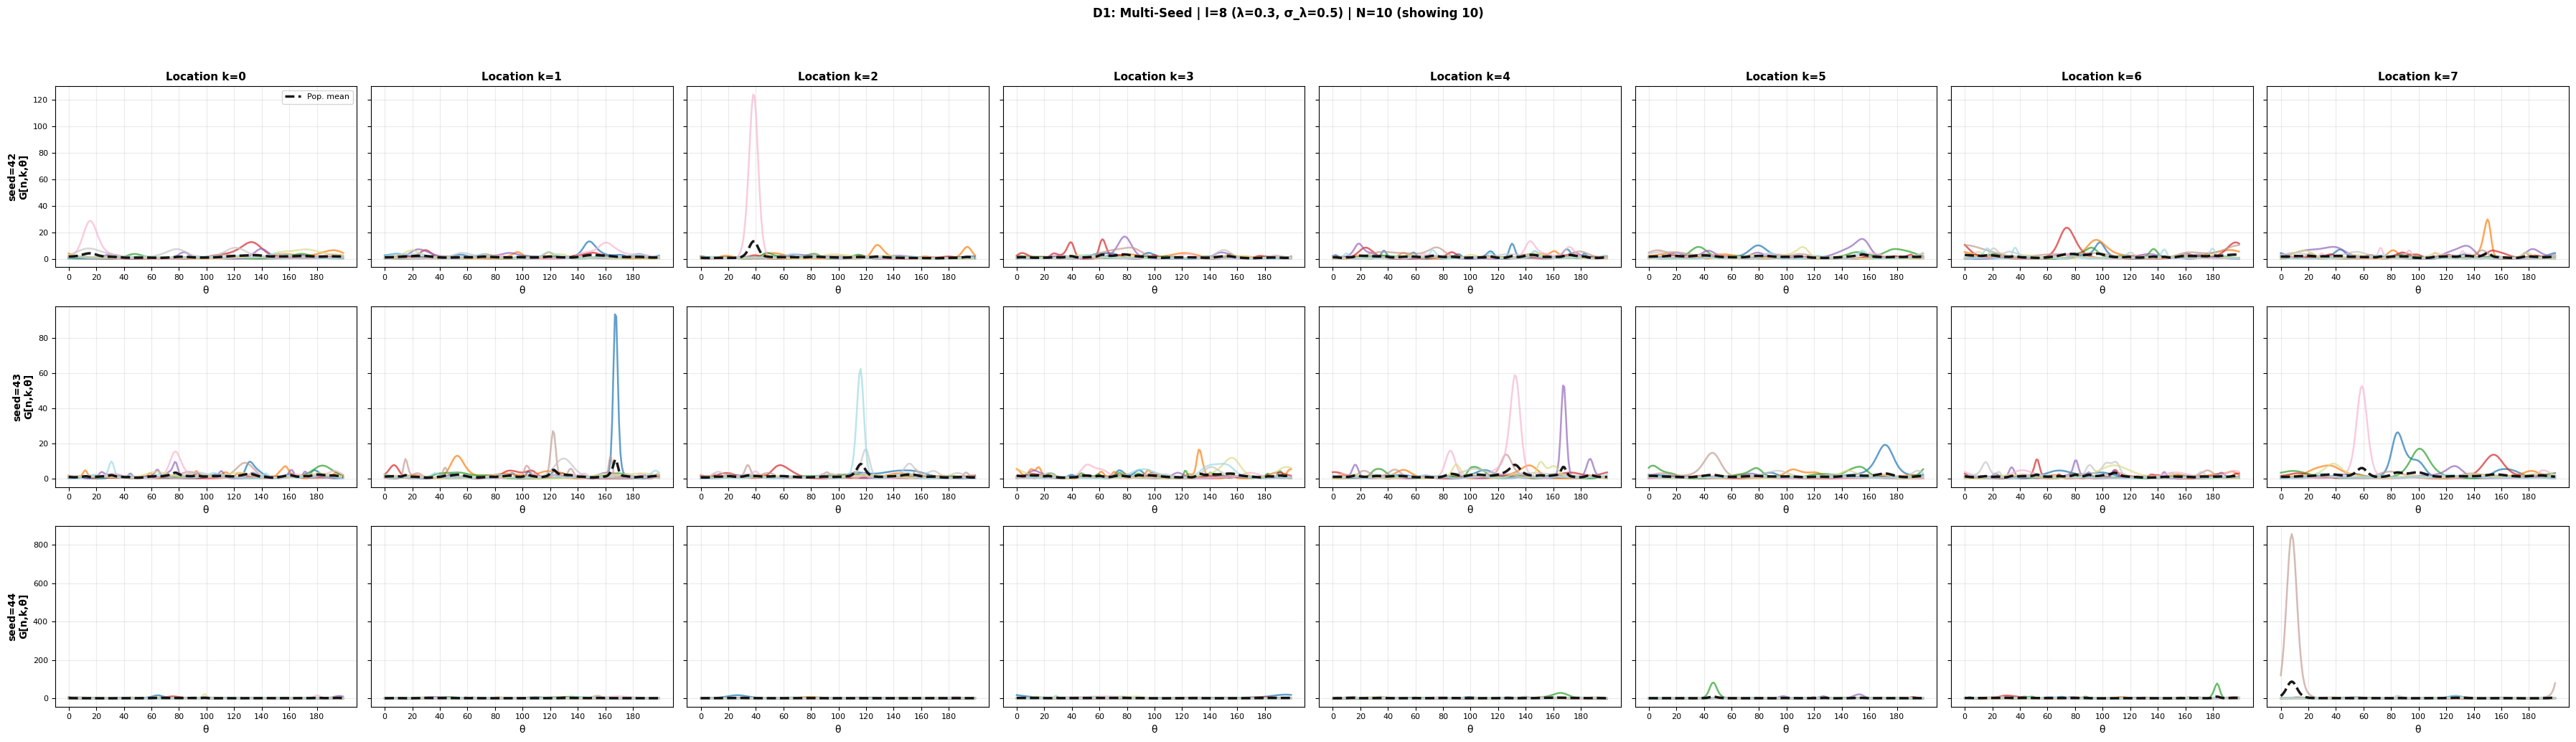

D1 plots done ✓


In [6]:
theta_axis  = np.arange(n_ori)
tick_step   = max(1, n_ori // 10)
theta_ticks = np.arange(0, n_ori, tick_step)

n_plot = min(N, 10)
cmap = plt.cm.get_cmap('tab20', n_plot)
colors = [cmap(i) for i in range(n_plot)]

for l in set_sizes:
    subset = subsets_per_l[l]
    nl = len(subset)
    ns = len(d_seeds)

    fig, axes = plt.subplots(ns, nl, figsize=(4.5*nl, 3.5*ns), squeeze=False, sharey='row')
    for row, s in enumerate(d_seeds):
        G = d1_G[s]
        for col, k in enumerate(subset):
            ax = axes[row, col]
            for ni in range(n_plot):
                ax.plot(theta_axis, G[ni, k, :], color=colors[ni], lw=1.8, alpha=0.7)
            ax.plot(theta_axis, G[:n_plot, k, :].mean(0), 'k--', lw=2.5, alpha=0.9,
                    label='Pop. mean' if col==0 else None)
            ax.set_xlabel('θ'); ax.set_xticks(theta_ticks); ax.tick_params(labelsize=8)
            ax.grid(True, alpha=0.25)
            if col == 0: ax.set_ylabel(f'seed={s}\nG[n,k,θ]', fontsize=10, fontweight='bold')
            if row == 0: ax.set_title(f'Location k={k}', fontsize=11, fontweight='bold')
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f'D1: Multi-Seed | l={l} (λ={cfg["lambda_base"]}, σ_λ={cfg["sigma_lambda"]}) | N={N} (showing {n_plot})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.94])
    plt.savefig(OUTPUT_DIR / f'plot_D1_l{l}_N{N}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("D1 plots done ✓")


### D2 — Multi-Lengthscale Plots

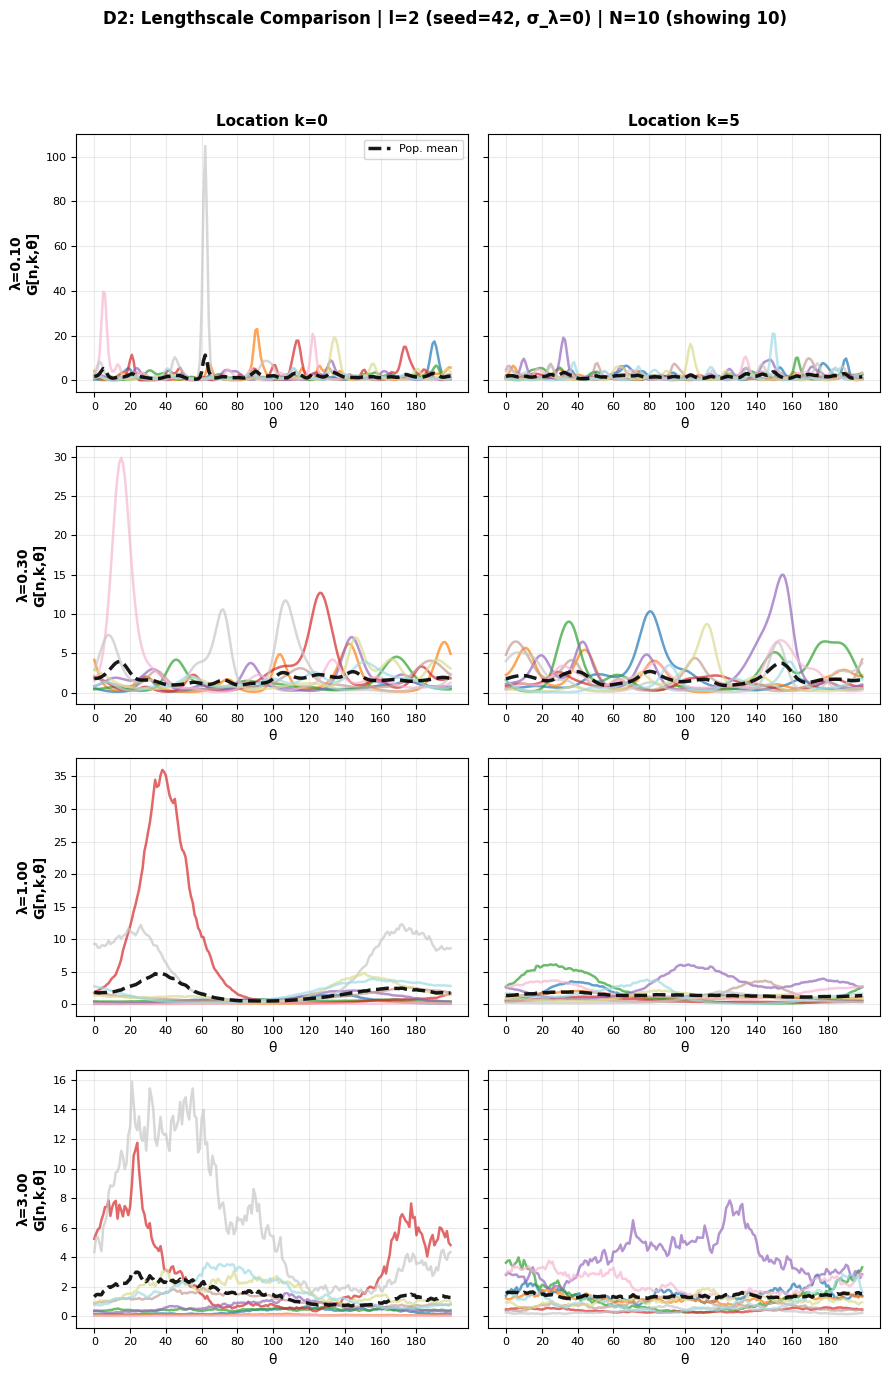

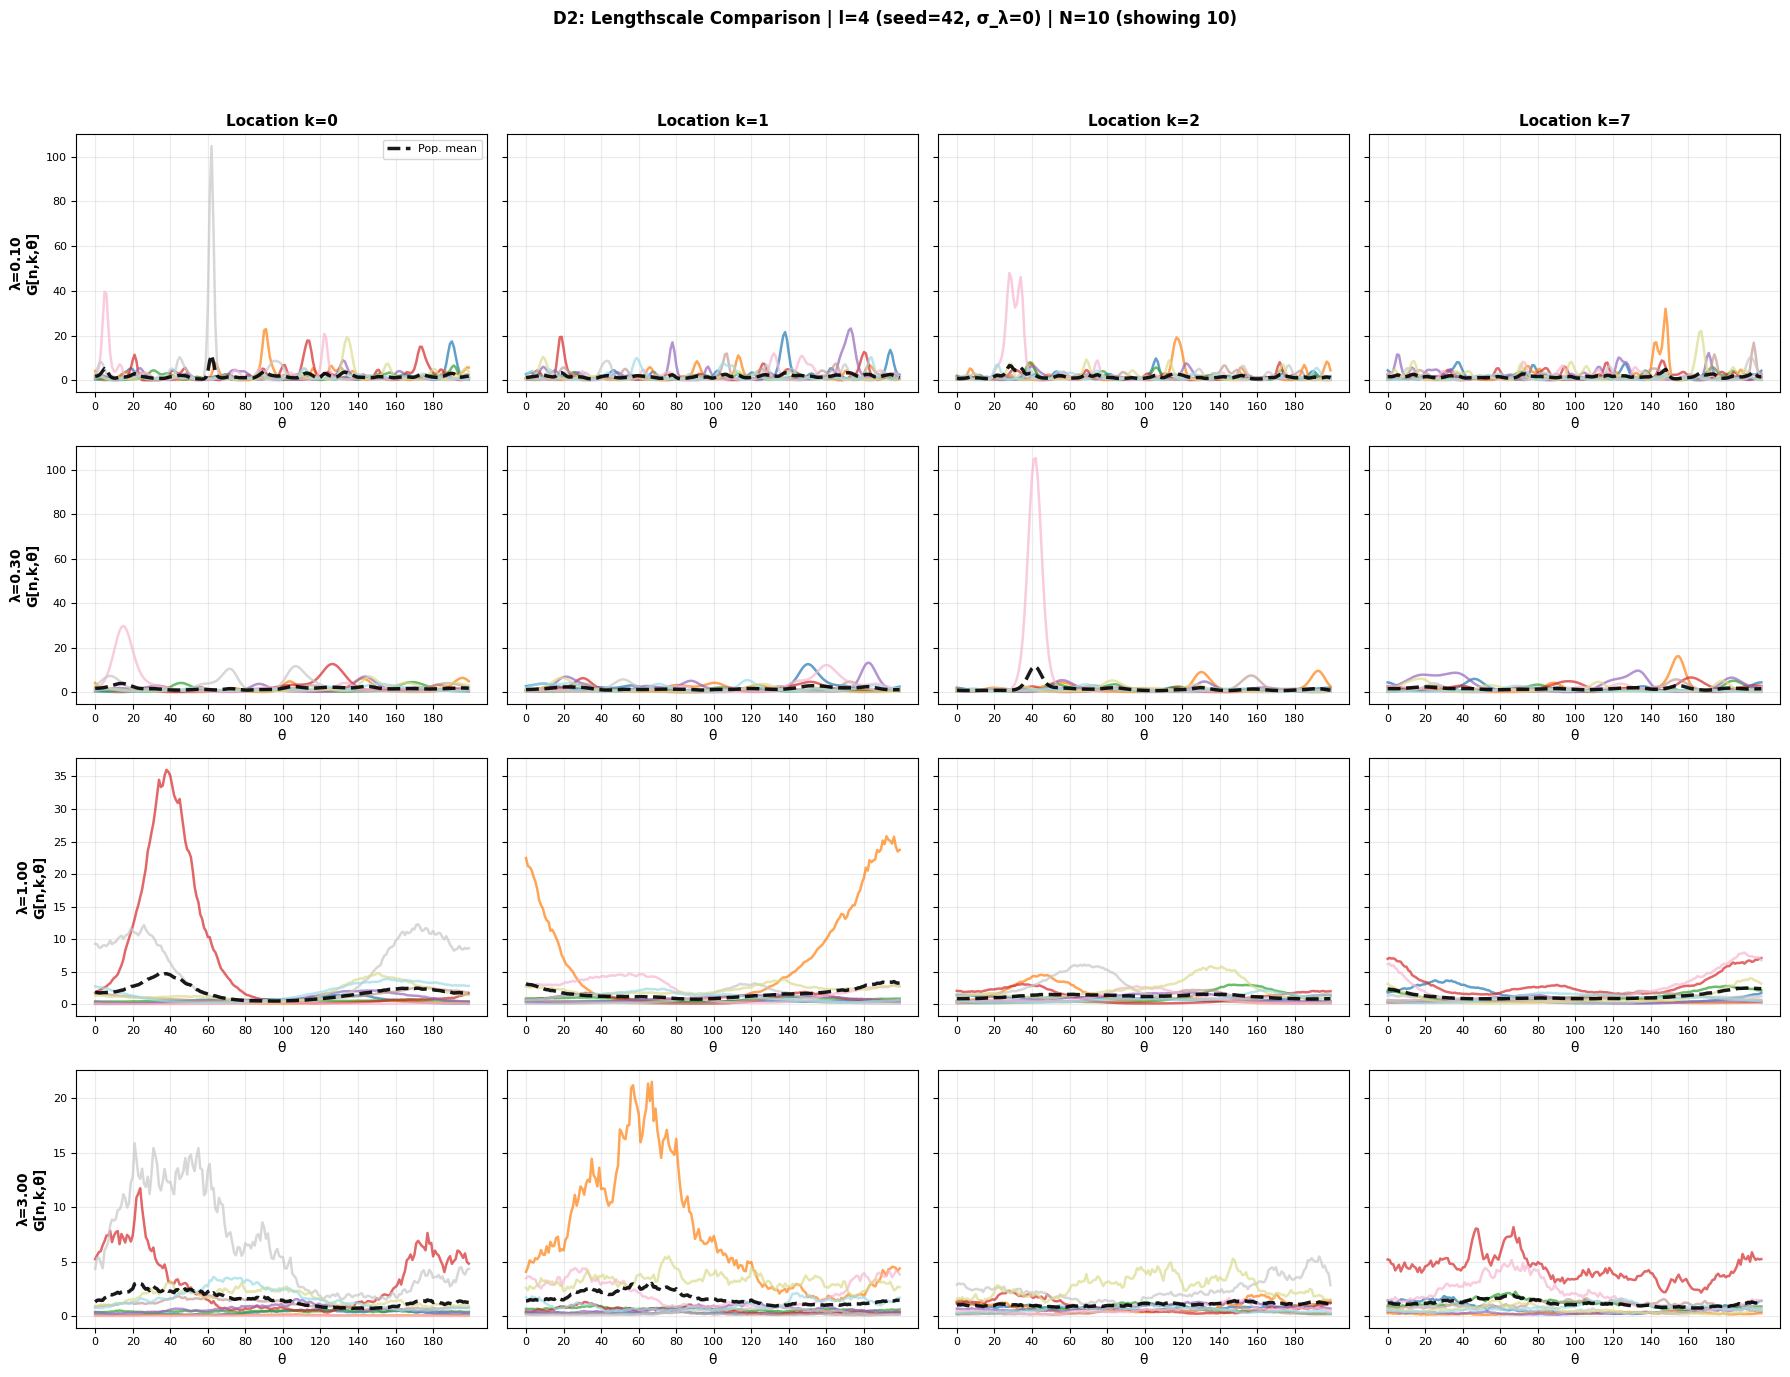

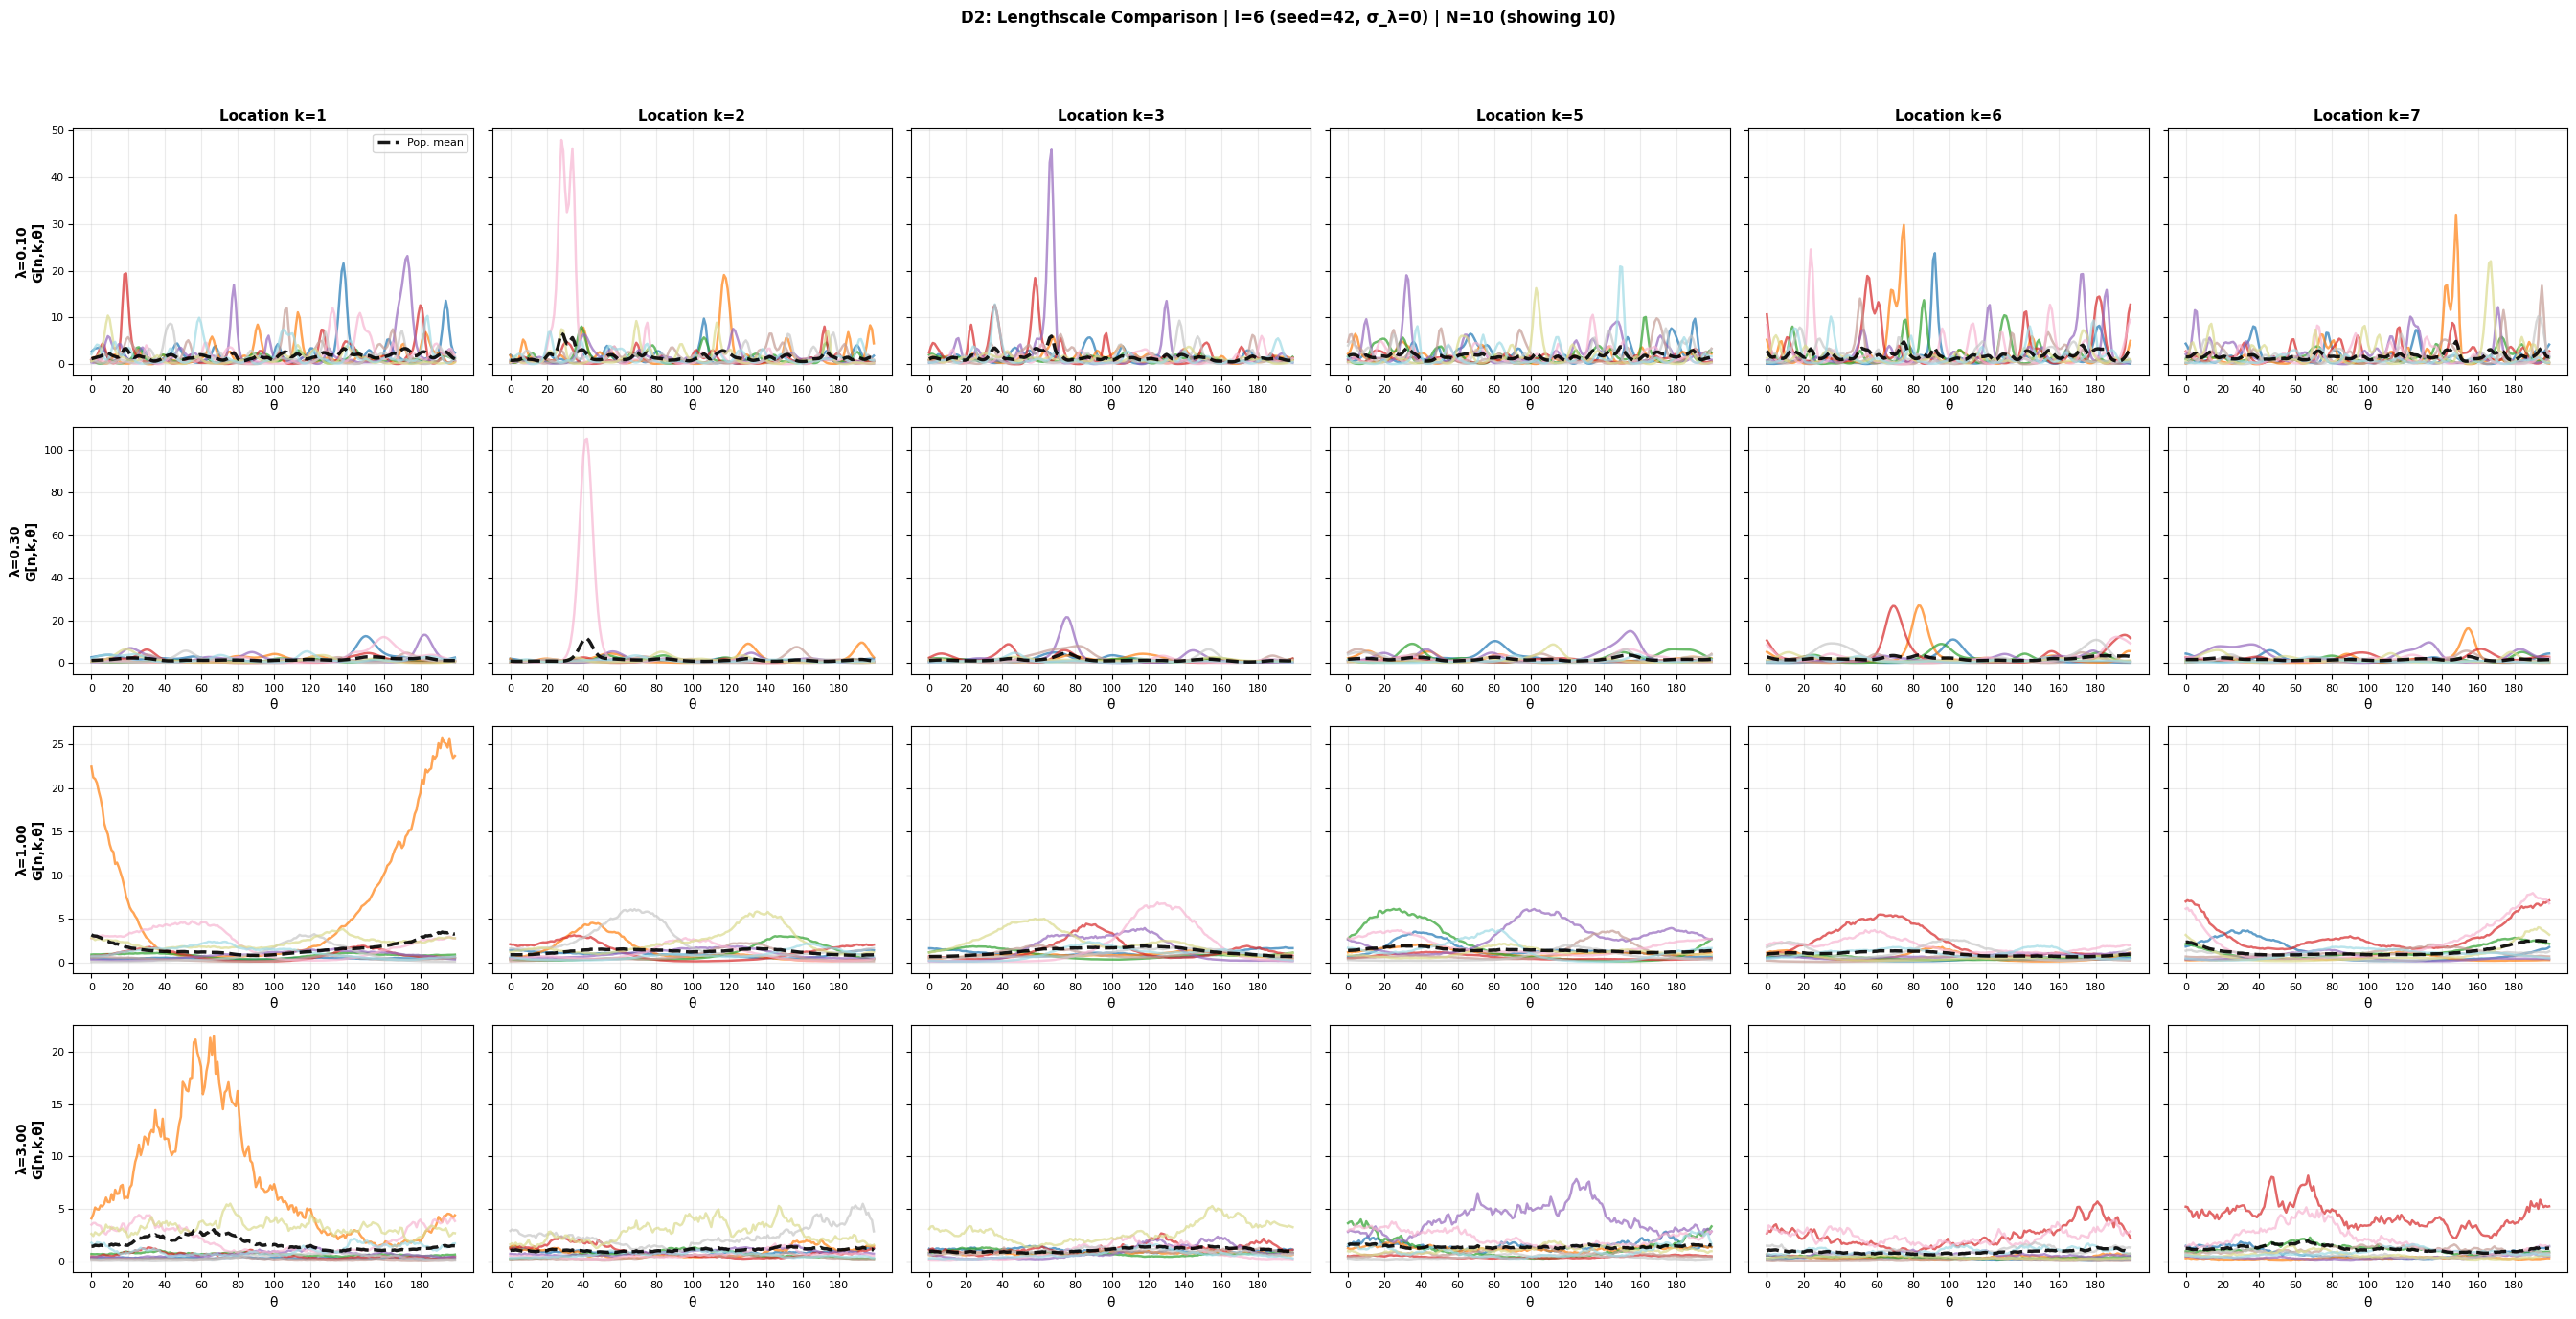

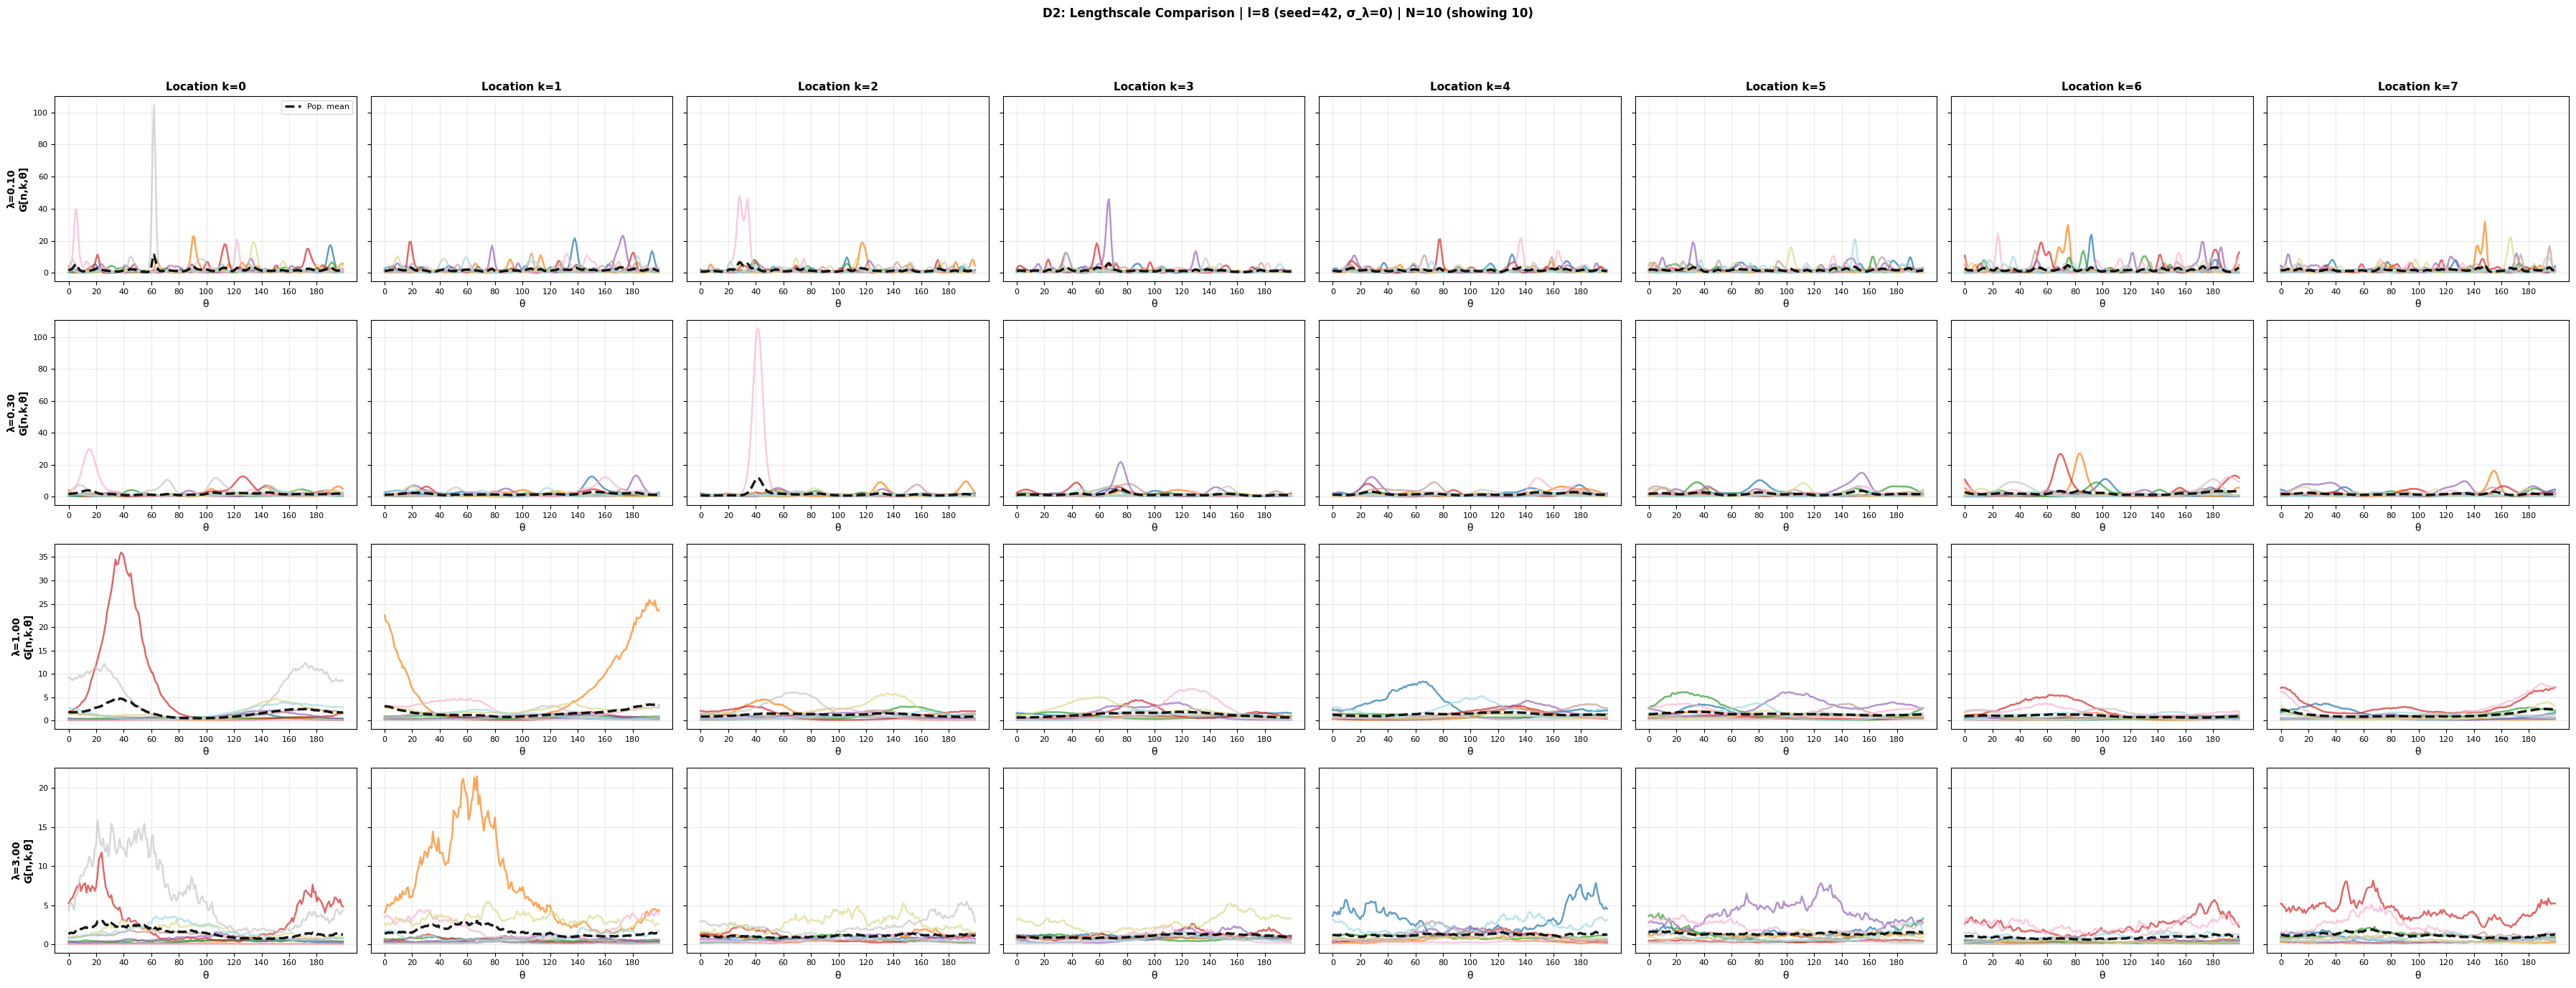

D2 plots done ✓

All plots saved to /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1/results/exp1_notebook


In [7]:
for l in set_sizes:
    subset = subsets_per_l[l]
    nl = len(subset)
    nlam = len(d_lambdas)

    fig, axes = plt.subplots(nlam, nl, figsize=(4.5*nl, 3.5*nlam), squeeze=False, sharey='row')
    for row, lam in enumerate(d_lambdas):
        G = d2_G[lam]
        for col, k in enumerate(subset):
            ax = axes[row, col]
            for ni in range(n_plot):
                ax.plot(theta_axis, G[ni, k, :], color=colors[ni], lw=1.8, alpha=0.7)
            ax.plot(theta_axis, G[:n_plot, k, :].mean(0), 'k--', lw=2.5, alpha=0.9,
                    label='Pop. mean' if col==0 else None)
            ax.set_xlabel('θ'); ax.set_xticks(theta_ticks); ax.tick_params(labelsize=8)
            ax.grid(True, alpha=0.25)
            if col == 0: ax.set_ylabel(f'λ={lam:.2f}\nG[n,k,θ]', fontsize=10, fontweight='bold')
            if row == 0: ax.set_title(f'Location k={k}', fontsize=11, fontweight='bold')
    axes[0,0].legend(fontsize=8)
    fig.suptitle(f'D2: Lengthscale Comparison | l={l} (seed={seed}, σ_λ=0) | N={N} (showing {n_plot})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.94])
    plt.savefig(OUTPUT_DIR / f'plot_D2_l{l}_N{N}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("D2 plots done ✓")
print(f"\nAll plots saved to {OUTPUT_DIR}")
